In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


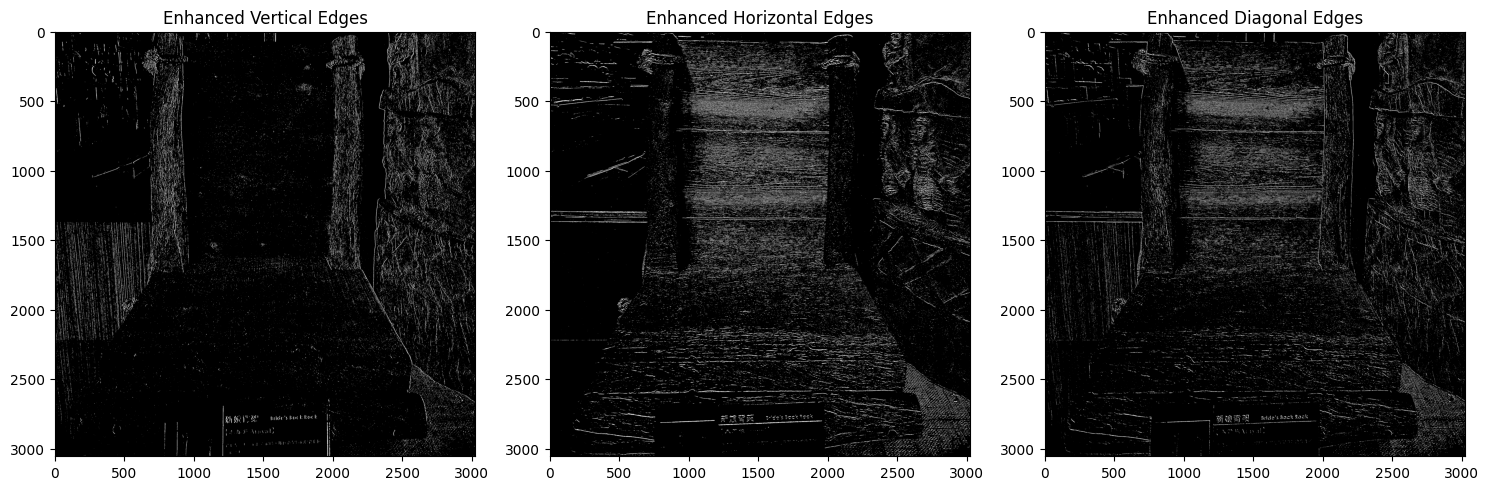

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 讀取影像
image = cv2.imread('drive/MyDrive/Colab/3.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 定義卷積核（直線、橫線、斜線）
vertical_kernel = np.array([[1, 0, -1],
                            [1, 0, -1],
                            [1, 0, -1]])

horizontal_kernel = np.array([[1, 1, 1],
                              [0, 0, 0],
                              [-1, -1, -1]])

diagonal_kernel = np.array([[0, 1, 1],
                            [-1, 0, 1],
                            [-1, -1, 0]])

# 執行卷積操作以獲得特徵圖
vertical_edges = cv2.filter2D(gray_image, -1, vertical_kernel)
horizontal_edges = cv2.filter2D(gray_image, -1, horizontal_kernel)
diagonal_edges = cv2.filter2D(gray_image, -1, diagonal_kernel)

# 進行閾值處理以增強邊緣特徵
_, thresholded_vertical = cv2.threshold(vertical_edges, 60, 255, cv2.THRESH_BINARY)
_, thresholded_horizontal = cv2.threshold(horizontal_edges, 60, 255, cv2.THRESH_BINARY)
_, thresholded_diagonal = cv2.threshold(diagonal_edges, 60, 255, cv2.THRESH_BINARY)

# 顯示並保存特徵圖
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresholded_vertical, cmap='gray')
plt.title('Enhanced Vertical Edges')
cv2.imwrite('drive/MyDrive/Colab/直線.jpg', thresholded_vertical)

plt.subplot(1, 3, 2)
plt.imshow(thresholded_horizontal, cmap='gray')
plt.title('Enhanced Horizontal Edges')
cv2.imwrite('drive/MyDrive/Colab/橫線.jpg', thresholded_horizontal)

plt.subplot(1, 3, 3)
plt.imshow(thresholded_diagonal, cmap='gray')
plt.title('Enhanced Diagonal Edges')
cv2.imwrite('drive/MyDrive/Colab/斜線.jpg', thresholded_diagonal)

plt.tight_layout()
plt.show()
